# Homogeneous elastic 2-D flat-free-surface benchmark: FD3 / convFD3 / OPT3 / SPECFEM2D

This benchmark isolates a flat traction-free interface in a homogeneous medium. FD and the strong collocation reference use an explicit zero-traction closure. OPT uses the natural weak form: integration by parts exposes `BoundaryFlux(σn, W)`, which vanishes for `σn = 0`; no separate strong boundary recipe is overlapped. SPECFEM2D is the reference. Side and bottom returns are excluded from the comparison window.


In [1]:
import Pkg
function find_flexopt_root(start=pwd())
    candidates = haskey(ENV, "FLEXOPT_ROOT") ? [ENV["FLEXOPT_ROOT"]] : String[]
    directory = abspath(start)
    while true
        push!(candidates, directory)
        parent = dirname(directory)
        parent == directory && break
        directory = parent
    end
    for candidate in unique(abspath.(expanduser.(candidates)))
        isfile(joinpath(candidate, "src", "flexOPT.jl")) && return candidate
    end
    error("Cannot locate flexOPT; set ENV[\"FLEXOPT_ROOT\"]")
end
flexopt_root = find_flexopt_root()
Pkg.activate(flexopt_root)
# Load the platform backend before flexOPT: batchGPU chooses CUDA, then
# Metal, and finally CPU. On this Apple machine it selects MetalBackend.
using Metal
include(joinpath(flexopt_root, "src", "batchFiles", "batchGPU.jl"))
backend isa KernelAbstractions.CPU && @warn(
    "No GPU backend is available; OPT recipes will be built on CPU")
@show backend
include(joinpath(flexopt_root, "src", "commonBatchs.jl"))
include(joinpath(flexopt_root, "src", "elasticWave2D.jl")) # ordinary FD explicit operators 
include(joinpath(flexopt_root, "src", "flexOPT.jl"))
include(joinpath(flexopt_root, "src", "specfemBenchmark.jl"))
using .commonBatchs, .elasticWave2D, .flexOPT, .specfemBenchmark
set_default_form!(:weak)
@assert DEFAULT_FORM[] === :weak
# CairoMakie renders static figures inline in IJulia/VS Code and can also
# render the MP4 frames below without opening a separate GLFW window.
using CairoMakie, Statistics, LinearAlgebra, SparseArrays, Base64, JLD2
CairoMakie.activate!(type="png")
@show VERSION Threads.nthreads() Base.active_project()


  Activating 

devs = Metal.devices() = Metal.MTL.MTLDeviceInstance[Metal.MTL.MTLDeviceInstance (object of type AGXG13XDevice)]

project at `~/Documents/Github/flexOPT`



→ Using Metal backend (1 device(s))
Selected backend type: MetalBackend
backend = MetalBackend()
VERSION = v"1.12.6"
Threads.nthreads() = 8
Base.active_project() = "/Users/nobuaki/Documents/Github/flexOPT/Project.toml"


"/Users/nobuaki/Documents/Github/flexOPT/Project.toml"

## Homogeneous half-space and flat surface


applyFreeSurface = true
applyCerjan = false
(nx, nz) = (241, 241)
sourcePosition = (x = -10000.0, z = -20000.0)
receiverZ = -10000.0
sourceFrequency = 0.6495
sourceDelay = 2.309468822170901
rickerSharpness = 1.5
sourceForce = 1.0e10
sourceMode = :gaussian
sourceSpatialSigma = 500.0
length(sourceSpecsReference) = 13
cerjanCells = 24
pointsPerSWavelength = (FD3 = 10.666666666666666, OPT3 = 10.666666666666666, OPT5 = 10.666666666666666)
earliestPEdgeArrival = 10.769822940723634
distanceToNearestArtificialEdge = 60000.0


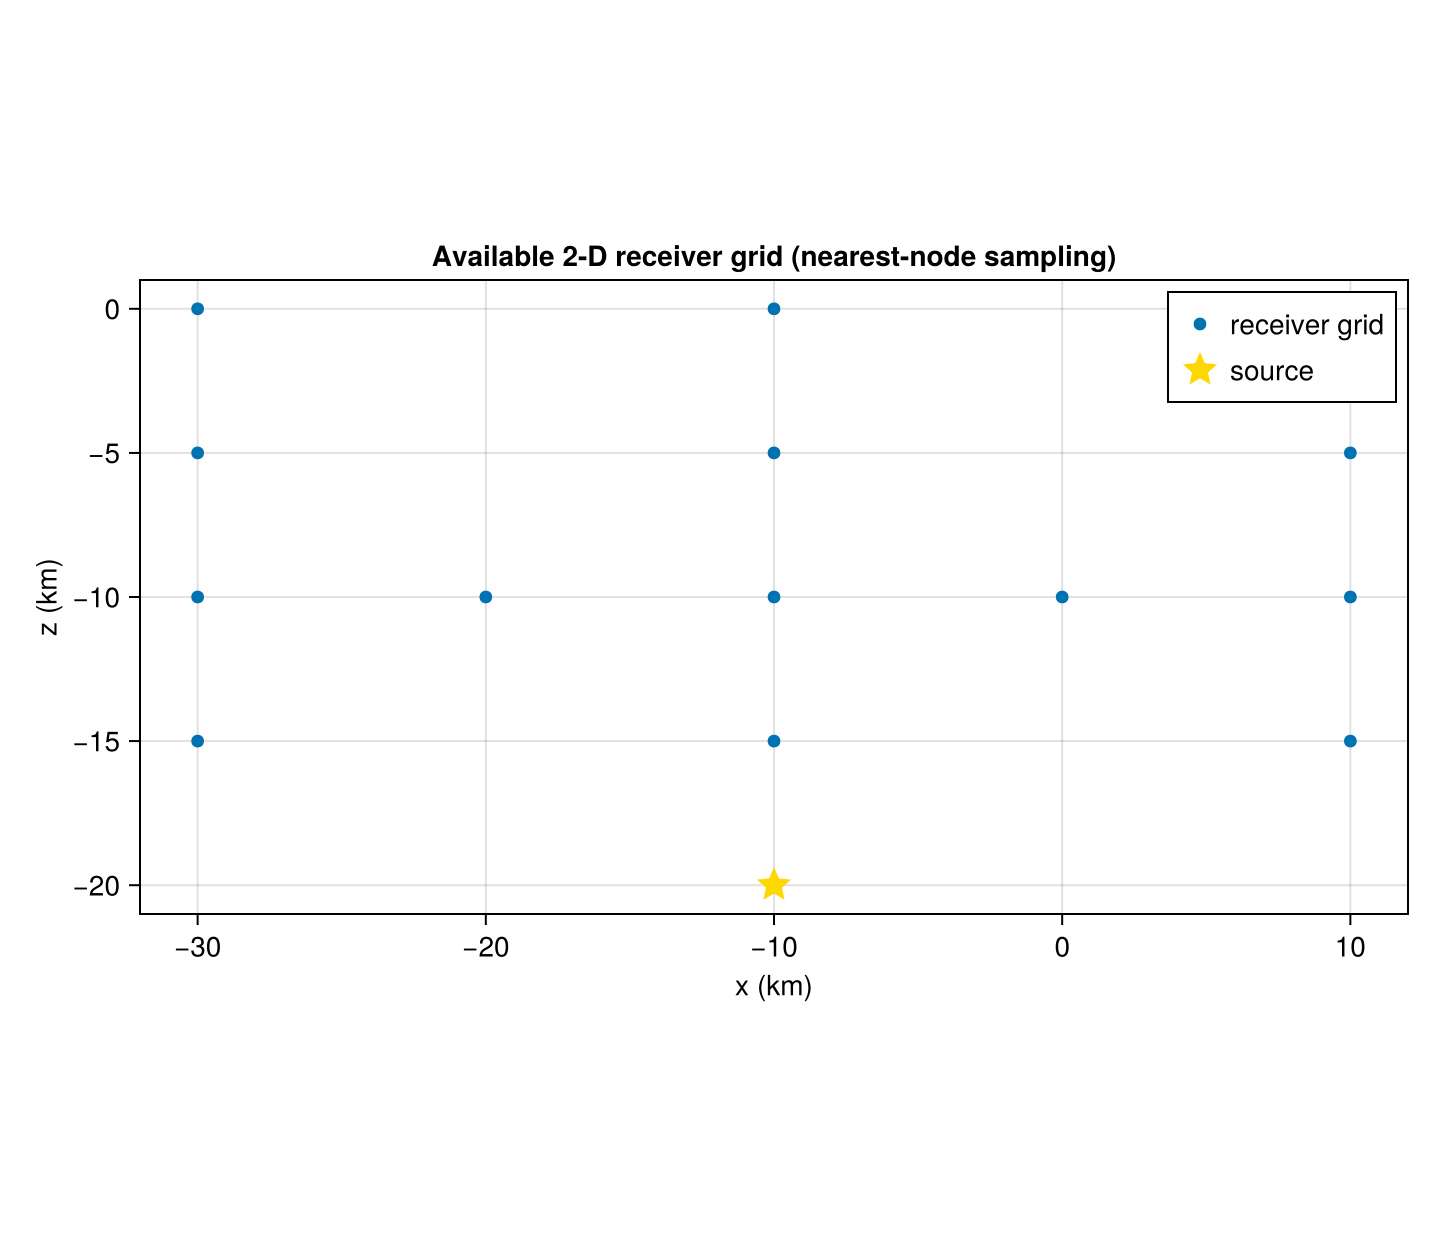

CairoMakie.Screen{IMAGE}


In [2]:
referenceDx = 500.0 # fixed physical source/SPECFEM reference scale
quickRun = true # true: 500 m diagnostic; false: 250 m comparison
fdOptSpatialRefinement = quickRun ? 1 : 2
dx = referenceDx / fdOptSpatialRefinement
optSpatialRefinement = 1 # FD3, convFD3 and OPT3 now share dx
buildHigherOrderRecipes = false # OPT4/OPT5 are outside this OPT3 boundary benchmark
runOPT4 = false # enable only after ElasticLHSOperatorAudit passes
runOPT5 = false # enable only after ElasticLHSOperatorAudit passes
optTimeMarchingScheme = :direct # or :predictor_corrector
optPredictorMode = :lumped_future # or :prepared
optCorrectorIterations = 3 # try 2 or 3 first; 12 is a convergence diagnostic
optCorrectorTolerance = 1e-8 # early exit when the full relative residual is small
optCorrectorRelaxation = 1.0
optTimeMarchingScheme in (:direct, :predictor_corrector) ||
    error("optTimeMarchingScheme must be :direct or :predictor_corrector")
optPredictorMode in (:lumped_future, :prepared) ||
    error("optPredictorMode must be :lumped_future or :prepared")
optCorrectorIterations >= 0 || error("optCorrectorIterations must be nonnegative")
runOPTWithoutGamma = false # keep the boundary benchmark to one OPT3 propagation
runConvFDBeyondBoundarySafeTime = false # boundary-truncation diagnostic only
waveformQuantity = :displacement # choose :velocity or :displacement
runSPECFEM2D = true # set false to reuse existing SPECFEM output files
waveformQuantity in (:velocity, :displacement) ||
    error("waveformQuantity must be :velocity or :displacement")
temporalRefinement = 2 # additional reduction of the OPT CFL time step
# Reduced homogeneous full space centred on the source. Its half-width
# is still checked below against the first possible P-wave edge arrival.
sourcePosition = (x=-10e3, z=-20e3)
domainHalfWidth = quickRun ? 60e3 : 90e3
x = collect((sourcePosition.x-domainHalfWidth):dx:
    (sourcePosition.x+domainHalfWidth))
applyFreeSurface = true
# No Cerjan layer is used: the time window excludes side and bottom returns.
# The z=0 interface is the intended physical traction-free boundary.
applyCerjan = false
z = collect((sourcePosition.z-domainHalfWidth):dx:
    (sourcePosition.z+domainHalfWidth))
nx, nz = length(x), length(z)
vp0, vs0, rho0 = 6000.0, 3464.0, 2700.0
material = applyFreeSurface ?
    repeat(reshape(z .<= 0.0, 1, :), nx, 1) : trues(nx, nz)
# Exactly homogeneous solid below z=0; cells above z=0 are void and exist
# only so the material/void interface is represented explicitly.
vpField = fill(vp0, nx, nz)
vsField = fill(vs0, nx, nz)
rhoField = fill(rho0, nx, nz)
model = (ρ=rhoField ./ 1e3, Vpv=vpField ./ 1e3,
    Vsv=vsField ./ 1e3)
vpMaximum, vsMinimum = vp0, vs0
cerjanCells = round(Int, 24 * referenceDx / dx)
cerjan = CerjanBoundarySpec(
    (cerjanCells, cerjanCells),
    (cerjanCells, 0);
    damping=0.0053 / fdOptSpatialRefinement^2,
)
activeCerjan = applyCerjan ? cerjan : nothing
bcFD = applyFreeSurface ?
    boundary_geometry(material, (dx, dx); cerjan=activeCerjan) :
    BoundaryConditionSet(free_surface=nothing, cerjan=activeCerjan,
        material_mask=BitArray(material), free_surface_mode=:pinned_void)
receiverZ = -10e3 # main horizontal comparison line
receiverX = quickRun ? [-30e3, -20e3, -10e3, 0.0, 10e3] :
    [-20e3, -10e3, 0.0, 10e3, 20e3]
# A reusable 2-D receiver geometry. The original horizontal line remains
# the lightweight default for the multi-solver plots below.
receiverGridX = quickRun ? [-30e3, -10e3, 10e3] :
    collect(-40e3:10e3:20e3)
receiverGridZ = quickRun ? [0.0, -5e3, -10e3, -15e3] :
    [0.0, -5e3, -10e3, -15e3, -25e3]
receiverGrid = unique(vcat(
    [(x=xr, z=zr) for zr in receiverGridZ for xr in receiverGridX
        if hypot(xr - sourcePosition.x, zr - sourcePosition.z) >= 5e3],
    [(x=xr, z=receiverZ) for xr in receiverX],
))
receiverBoundaryMargins = [minimum((
    station.x - first(x), last(x) - station.x,
    station.z - first(z), last(z) - station.z,
)) for station in receiverGrid]
@assert minimum(receiverBoundaryMargins) >= (quickRun ? 20e3 : 30e3)
duration = quickRun ? 9.0 : 14.0
outputSampling = 0.10
# A three-point stencil needs a well-resolved shortest (S) wavelength.
# The source band is fixed by the reference 500 m grid. Refining OPT then
# measures discretization convergence without changing the physical source.
referencePointsPerSWavelength = 16
rickerSharpness = 1.5 # 1.0 is the former broader pulse
minimumAcceptedPointsPerSWavelength = 10
coarsestSpacing = referenceDx # preserve the physical Ricker band
sourceFrequency = rickerSharpness * vs0 /
    (referencePointsPerSWavelength * coarsestSpacing)
sourceDelay = 1.5 / sourceFrequency
sourceForce = 1.0e10 # N/m: total vertical line force in a unit-thickness slice
sourceMode = :gaussian # :point or :gaussian
sourceSpatialSigma = referenceDx # fixed while FD/OPT are refined
sourceCutoffSigmas = 2.0
sourceMode in (:point, :gaussian) || error("sourceMode must be :point or :gaussian")
function spatial_source_specs(xaxis, zaxis; center=sourcePosition,
    mode=sourceMode, sigma=sourceSpatialSigma, cutoff=sourceCutoffSigmas)
    if mode === :point
        return [(x=xaxis[argmin(abs.(xaxis .- center.x))],
            z=zaxis[argmin(abs.(zaxis .- center.z))], weight=1.0)]
    end
    specs = [(x=Float64(xv), z=Float64(zv),
        weight=exp(-((xv-center.x)^2 + (zv-center.z)^2) / (2sigma^2)))
        for xv in xaxis for zv in zaxis
        if hypot(xv-center.x, zv-center.z) <= cutoff*sigma]
    total = sum(s.weight for s in specs)
    [(x=s.x, z=s.z, weight=s.weight / total) for s in specs]
end
sourceSpecsReference = spatial_source_specs(x, z)
@assert isapprox(sum(s.weight for s in sourceSpecsReference), 1.0; atol=1e-14)
rickerSource(time) = begin
    a = π * sourceFrequency * (time - sourceDelay)
    (1 - 2a^2) * exp(-a^2)
end
pointsPerSWavelength = (
    FD3=vsMinimum / (sourceFrequency * dx),
    OPT3=vsMinimum / (sourceFrequency * (dx / optSpatialRefinement)),
    OPT5=vsMinimum / (sourceFrequency * (dx / optSpatialRefinement)),
)
distanceToNearestArtificialEdge = minimum((
    sourcePosition.x - first(x), last(x) - sourcePosition.x,
    sourcePosition.z - first(z),
))
significantSourceStart = sourceDelay - 1 / sourceFrequency
earliestPEdgeArrival = significantSourceStart +
    distanceToNearestArtificialEdge / vpMaximum
@assert duration < earliestPEdgeArrival
@assert minimum(values(pointsPerSWavelength)) >=
    minimumAcceptedPointsPerSWavelength
@show applyFreeSurface applyCerjan (nx, nz) sourcePosition receiverZ
@show sourceFrequency sourceDelay rickerSharpness sourceForce sourceMode
@show sourceSpatialSigma length(sourceSpecsReference) cerjanCells
@show pointsPerSWavelength earliestPEdgeArrival distanceToNearestArtificialEdge
receiverGeometryFigure = Figure(size=(720, 620))
receiverGeometryAxis = Axis(receiverGeometryFigure[1, 1];
    xlabel="x (km)", ylabel="z (km)", aspect=DataAspect(),
    title="Available 2-D receiver grid (nearest-node sampling)")
scatter!(receiverGeometryAxis, getproperty.(receiverGrid, :x) ./ 1e3,
    getproperty.(receiverGrid, :z) ./ 1e3; label="receiver grid")
scatter!(receiverGeometryAxis, [sourcePosition.x / 1e3],
    [sourcePosition.z / 1e3]; marker=:star5, markersize=20,
    color=:gold, strokecolor=:black, label="source")
axislegend(receiverGeometryAxis)
display(receiverGeometryFigure)


## FD3: zero-traction stress flux at z=0


In [3]:
fdConfig = ElasticThreePointConfig2D(
    pointsInSpace=3, pointsInTime=3, supplementaryOrder=2, cfl=0.38,
)
fd = prepare_elastic_wave_2d(
    model, (dx, dx);
    material_mask=material,
    boundary_conditions=bcFD,
    config=fdConfig,
)
fdCoordinates = elastic_wave_coordinates(x, z, fd)
fdPadding = fd.padding
sourcePhysical = CartesianIndex(
    argmin(abs.(x .- sourcePosition.x)),
    argmin(abs.(z .- sourcePosition.z)),
)
sourceFD = sourcePhysical + CartesianIndex(Tuple(fdPadding[1, :]))
sourceSpecsFD = spatial_source_specs(fdCoordinates.x, fdCoordinates.z)
sourceNodesFD = [(index=CartesianIndex(
    argmin(abs.(fdCoordinates.x .- s.x)),
    argmin(abs.(fdCoordinates.z .- s.z))), weight=s.weight)
    for s in sourceSpecsFD]
fdSteps = ceil(Int, duration / fd.dt)
fdOutputStride = max(1, round(Int, outputSampling / fd.dt))
fdFramesX = Matrix{Float32}[copy(fd.ux)]
fdFramesZ = Matrix{Float32}[copy(fd.uz)]
fdTimes = Float64[0.0]
for step in 1:fdSteps
    step_elastic_wave_2d!(fd)
    for sourceNode in sourceNodesFD
        elasticWave2D.add_ricker_source!(
            fd, sourceNode.index;
            f0=sourceFrequency, t0=sourceDelay,
            amplitude=sourceForce * sourceNode.weight,
            component=:z, source_kind=:force,
        )
    end
    if step % fdOutputStride == 0 || step == fdSteps
        push!(fdFramesX, copy(fd.ux))
        push!(fdFramesZ, copy(fd.uz)); push!(fdTimes, fd.time)
    end
end
uxFD = cat(fdFramesX...; dims=3)
uzFD = cat(fdFramesZ...; dims=3)
@show fd.dt size(uzFD) maximum(abs, uxFD) maximum(abs, uzFD)


fd.dt = 0.022391716f0
size(uzFD) = (241, 241, 102)
maximum(abs, uxFD) = 0.01793192f0
maximum(abs, uzFD) = 0.07854081f0


0.07854081f0

## OPT natural weak volume operator (`σn = 0`)


In [4]:
dxOPT = dx / optSpatialRefinement
xOPTPhysical = collect(first(x):dxOPT:last(x))
zOPTPhysical = collect(first(z):dxOPT:last(z))
solidOPT = applyFreeSurface ?
    repeat(reshape(zOPTPhysical .<= 0.0, 1, :),
        length(xOPTPhysical), 1) :
    trues(length(xOPTPhysical), length(zOPTPhysical))
dtOPT = 0.20 * dxOPT / (sqrt(2) * vpMaximum * temporalRefinement)
vpFieldOPT = fill(vp0, size(solidOPT))
vsFieldOPT = fill(vs0, size(solidOPT))
rhoFieldOPT = fill(rho0, size(solidOPT))
# Stable reference used by the previously working OPT benchmark. This is
# an exact change of coordinates x'=x/Δx, z'=z/Δz, t'=t/Δt, not a
# change of the physical model. The direct physical-recipe path remains
# available for conditioning experiments, but is not the benchmark default.
optFormulation = :scaled_coordinates # or :physical_recipe_experimental
if optFormulation === :scaled_coordinates
    recipeSpacing = (1.0, 1.0, 1.0)
    rhoOPT = rhoFieldOPT ./ rho0
    muOPT = (rhoFieldOPT .* vsFieldOPT.^2 ./ rho0) .* (dtOPT/dxOPT)^2
    lambdaOPT = (rhoFieldOPT .* (vpFieldOPT.^2 .- 2vsFieldOPT.^2) ./ rho0) .*
        (dtOPT/dxOPT)^2
elseif optFormulation === :physical_recipe_experimental
    recipeSpacing = (dxOPT, dxOPT, dtOPT)
    rhoOPT = rhoFieldOPT
    muOPT = rhoFieldOPT .* vsFieldOPT.^2
    lambdaOPT = rhoFieldOPT .* (vpFieldOPT.^2 .- 2vsFieldOPT.^2)
else
    error("unknown optFormulation=$optFormulation")
end
muOPT[.!solidOPT] .= 0.0
lambdaOPT[.!solidOPT] .= 0.0
optParameters = Dict{String,Any}(
    "famousEquationType" => "2DsismoTimeIsoHeteroSingleForce",
    "Δ" => recipeSpacing,
    "orderBtime" => 1, "orderBspace" => 1,
    "pointsInSpace" => 3, "pointsInTime" => 3,
    "supplementaryOrder" => 2,
    # Materialise the global choice in the recipe and its cache key.
    "variationalForm" => DEFAULT_FORM[],
    # Preserve all total-degree <= 2 Taylor conditions exactly; use
    # supplementaryOrder only to optimise the remaining null space.
    "taylorInverseMode" => :hierarchical_constrained,
    "fieldItpl" => (ptsSpace=1, ptsTime=1, offsetSpace=1.0,
        offsetTime=1, YorderBspace=-1, YorderBtime=-1),
    "materItpl" => (ptsSpace=1, ptsTime=1, offsetSpace=1.0,
        offsetTime=1, YorderBspace=-1, YorderBtime=-1),
    # The expensive semi-symbolic coefficient construction runs on the
    # GPU selected in the bootstrap cell (Metal here).
    "recipe_backend" => backend,
)
# Cache complete semi-symbolic recipes, not the very large prepared
# operators. The runtime Metal/CPU object is deliberately excluded from
# the cache key and is injected only when a recipe must be produced.
recipeCacheDirectory = "semiSymbolic"
recipeCacheVersion = 8 # corrected overlapping B-spline supports at clipped surfaces
function cachedOPTRecipe(parameters, prefix; existing=nothing)
    cacheParameters = Dict{String,Any}(
        key => value for (key, value) in parameters
        if key != "recipe_backend"
    )
    cacheParameters["recipe_cache_version"] = recipeCacheVersion
    function produceRecipe(config)
        runtimeParameters = Dict{String,Any}(config)
        pop!(runtimeParameters, "hash_id", nothing)
        pop!(runtimeParameters, "recipe_cache_version", nothing)
        runtimeParameters["recipe_backend"] = backend
        isnothing(existing) ?
            makeOPTsemiSymbolic(runtimeParameters) : existing
    end
    myProduceOrLoad(produceRecipe, cacheParameters,
        recipeCacheDirectory, prefix)
end
existingOPT3Recipe = @isdefined(optRecipe) ? optRecipe : nothing
optRecipe = cachedOPTRecipe(optParameters, "elastic2D_OPT3";
    existing=existingOPT3Recipe)
# Two genuine solid-side surface geometries.  The first translates the
# complete 3×3 box below the surface.  The second uses only the available
# 3×2 nodes and preserves every independent degree-≤2 Taylor term.
shiftedSurfaceParameters = copy(optParameters)
shiftedSurfaceParameters["nuCentre"] = (2, 3)
shiftedSurfaceRecipe = cachedOPTRecipe(shiftedSurfaceParameters,
    "elastic2D_OPT3_surface_shifted_full")
clippedSurfaceParameters = copy(optParameters)
clippedSurfaceParameters["pointsInSpace"] = (3, 2)
clippedSurfaceParameters["nuCentre"] = (2, 2)
clippedSurfaceParameters["fieldItpl"] = (
    ptsSpace=(3, 2), ptsTime=1, offsetSpace=(0.0, 0.0),
    offsetTime=1, YorderBspace=1, YorderBtime=-1,
)
# The field/material reconstruction uses only the available 3×2 solid
# nodes. Wν nevertheless remains the centred three-point test function;
# its integral is clipped at the physical surface z=2.
clippedSurfaceParameters["trialFunctionRefPoints"] = (
    (1, 2, 3), (1, 2, 3), (1, 2, 3),
)
clippedSurfaceParameters["testIntegrationBounds"] = (
    (1.0, 3.0), (1.0, 2.0), (1.0, 3.0),
)
clippedSurfaceParameters["exactTaylorTotalDegree"] = 2
clippedSurfaceRecipe = cachedOPTRecipe(clippedSurfaceParameters,
    "elastic2D_OPT3_surface_clipped_available")
# P-C predictor: same three-point support and physical model, but only
# the supplementary Taylor optimisation is removed. The full OPT3
# operator remains the residual operator used by every correction.
optPredictorParameters = copy(optParameters)
optPredictorParameters["supplementaryOrder"] = 0
optPredictorRecipe = optTimeMarchingScheme === :predictor_corrector &&
    optPredictorMode === :prepared ?
    cachedOPTRecipe(optPredictorParameters, "elastic2D_OPT3_predictor_s0") : nothing

# Four/five-point spatial recipes; time remains a three-point stencil.
opt4Parameters = copy(optParameters)
opt4Parameters["pointsInSpace"] = 4
opt4Parameters["fieldItpl"] = merge(optParameters["fieldItpl"],
    (offsetSpace=1.5,))
opt4Parameters["materItpl"] = merge(optParameters["materItpl"],
    (offsetSpace=1.5,))
opt4Recipe = buildHigherOrderRecipes ? cachedOPTRecipe(
    opt4Parameters, "elastic2D_OPT4"; existing=nothing) : nothing

# Five-point OPT recipe: the time stencil remains three points so that
# only the spatial approximation changes relative to OPT3.
opt5Parameters = copy(optParameters)
# Validated OPT5 family used by seismo1Dbenchmark: five trial points
# retain the linear B-spline test order. orderBspace=3 is not OPT5 and
# generated a nearly singular first-step solve in this elastic problem.
opt5Parameters["orderBspace"] = 1
opt5Parameters["pointsInSpace"] = 5
opt5Parameters["fieldItpl"] = merge(optParameters["fieldItpl"],
    (offsetSpace=2.0,))
opt5Parameters["materItpl"] = merge(optParameters["materItpl"],
    (offsetSpace=2.0,))
# Keep OPT5 available, but do not even load/build it in the quick run.
# When enabled, never migrate the former invalid orderBspace=3 object.
opt5Recipe = buildHigherOrderRecipes ? cachedOPTRecipe(
    opt5Parameters, "elastic2D_OPT5"; existing=nothing) : nothing

# Collocation/delta-test recipe corresponding to the conventional FD3
# definition used in seismo1Dbenchmark.ipynb. Keep it beside OPT3: it is
# a coefficient reference, not an alias for the explicit flux solver.
conventionalFDParameters = copy(optParameters)
conventionalFDParameters["orderBspace"] = -1
conventionalFDParameters["orderBtime"] = -1
conventionalFDParameters["supplementaryOrder"] = 0
conventionalFDParameters["variationalForm"] = :strong
existingConvFD3Recipe = @isdefined(conventionalFDRecipe) ?
    conventionalFDRecipe : nothing
conventionalFDRecipe = cachedOPTRecipe(
    conventionalFDParameters, "elastic2D_convFD3";
    existing=existingConvFD3Recipe)
recipeComparison = (
    conventionalFD3=(orderBspace=-1, orderBtime=-1,
        supplementaryOrder=0, pointsInSpace=3, pointsInTime=3),
    OPT3=(orderBspace=optParameters["orderBspace"],
        orderBtime=optParameters["orderBtime"],
        supplementaryOrder=optParameters["supplementaryOrder"],
        pointsInSpace=optParameters["pointsInSpace"],
        pointsInTime=optParameters["pointsInTime"]),
    OPT4=(orderBspace=opt4Parameters["orderBspace"],
        orderBtime=opt4Parameters["orderBtime"],
        supplementaryOrder=opt4Parameters["supplementaryOrder"],
        pointsInSpace=opt4Parameters["pointsInSpace"],
        pointsInTime=opt4Parameters["pointsInTime"]),
    OPT5=(orderBspace=opt5Parameters["orderBspace"],
        orderBtime=opt5Parameters["orderBtime"],
        supplementaryOrder=opt5Parameters["supplementaryOrder"],
        pointsInSpace=opt5Parameters["pointsInSpace"],
        pointsInTime=opt5Parameters["pointsInTime"]),
)
# Public handles for inspecting the complete symbolic recipes in IJulia,
# e.g. `optRecipes.OPT5["recette"]`.
optRecipes = (convFD3=conventionalFDRecipe, OPT3=optRecipe,
    OPT4=opt4Recipe, OPT5=opt5Recipe)
@show recipeComparison
if runOPT4 || runOPT5
    coefficientGatePath = joinpath(flexopt_root, "data",
        "elastic_lhs_coefficient_gate.jld2")
    isfile(coefficientGatePath) || error(
        "Run ElasticLHSOperatorAudit.ipynb before OPT4/OPT5 propagation")
    coefficientGate = load(coefficientGatePath)
    @assert all(result.passed for result in
        values(coefficientGate["coefficient_health"]))
end


recipeComparison = (conventionalFD3 = (orderBspace = -1, orderBtime = -1, supplementaryOrder = 0, pointsInSpace = 3, pointsInTime = 3), OPT3 = (orderBspace = 1, orderBtime = 1, supplementaryOrder = 2, pointsInSpace = 3, pointsInTime = 3), OPT4 = (orderBspace = 1, orderBtime = 1, supplementaryOrder = 2, pointsInSpace = 4, pointsInTime = 3), OPT5 = (orderBspace = 1, orderBtime = 1, supplementaryOrder = 2, pointsInSpace = 5, pointsInTime = 3))


In [5]:
optCerjan = CerjanBoundarySpec(
    (cerjan.lower[1] * optSpatialRefinement,
        cerjan.lower[2] * optSpatialRefinement),
    (cerjan.upper[1] * optSpatialRefinement, 0);
    damping=cerjan.damping / optSpatialRefinement^2,
)
activeOptCerjan = applyCerjan ? optCerjan : nothing
bcOPT = applyFreeSurface ?
    boundary_geometry(solidOPT, (dxOPT, dxOPT);
        free_surface_mode=:pinned_void, cerjan=activeOptCerjan) :
    BoundaryConditionSet(free_surface=nothing, cerjan=activeOptCerjan,
        material_mask=BitArray(solidOPT), free_surface_mode=:pinned_void)
# The strong collocation reference still needs an explicit discrete
# zero-traction closure; only the weak OPT recipe has the natural flux.
bcConvFD = applyFreeSurface ?
    boundary_geometry(solidOPT, (dxOPT, dxOPT);
        free_surface_mode=:zero_traction_flux, cerjan=activeOptCerjan) : bcOPT
modelsOPT = [rhoOPT, lambdaOPT, muOPT]
pointsOPT = getModelPoints(modelsOPT[1], 3,
    optRecipe["recette"].numbersOfTheSystem.numbersOfTheSystemL.timeMarching)
familyOPT = (models=modelsOPT, modelPoints=pointsOPT,
    Δ=recipeSpacing, modelName="homogeneous_OPT3_$(optFormulation)")
operatorTimings = Dict{Symbol,Float64}()
timedOPT3Assembly = @timed numericalOperatorConstruction(Dict{String,Any}(
    "optRec" => optRecipe, "modelFam" => familyOPT,
    "absorbingBoundaries" => nothing,
    "maskedRegionInSpace" => nothing,
    "boundaryConditions" => bcOPT,
    "representation" => "matrixfree",
))["numOperators"]
numericalVolume = timedOPT3Assembly.value
operatorTimings[:OPT3_assembly] = timedOPT3Assembly.time
timedOPT3Preparation = @timed prepareLinearSystem(numericalVolume;
    free_surface_spacing=recipeSpacing[1:2])
preparedVolume = timedOPT3Preparation.value
operatorTimings[:OPT3_preparation] = timedOPT3Preparation.time
preparedPredictorVolume = if optTimeMarchingScheme === :predictor_corrector &&
    optPredictorMode === :prepared
    predictorPoints = getModelPoints(modelsOPT[1], 3,
        optPredictorRecipe["recette"].numbersOfTheSystem.numbersOfTheSystemL.timeMarching)
    predictorFamily = (models=modelsOPT, modelPoints=predictorPoints,
        Δ=recipeSpacing, modelName="homogeneous_free_surface_OPT3_predictor_s0_$(optFormulation)")
    timedPredictorAssembly = @timed numericalOperatorConstruction(Dict{String,Any}(
        "optRec" => optPredictorRecipe, "modelFam" => predictorFamily,
        "absorbingBoundaries" => nothing, "maskedRegionInSpace" => nothing,
        "boundaryConditions" => bcOPT, "representation" => "matrixfree",
    ))["numOperators"]
    operatorTimings[:OPT3_predictor_assembly] = timedPredictorAssembly.time
    timedPredictorPreparation = @timed prepareLinearSystem(
        timedPredictorAssembly.value; free_surface_spacing=recipeSpacing[1:2])
    operatorTimings[:OPT3_predictor_preparation] = timedPredictorPreparation.time
    timedPredictorPreparation.value
else
    nothing
end
preparedOPT4Volume = if runOPT4
    pointsOPT4 = getModelPoints(modelsOPT[1], 4,
        opt4Recipe["recette"].numbersOfTheSystem.numbersOfTheSystemL.timeMarching)
    familyOPT4 = (models=modelsOPT, modelPoints=pointsOPT4,
        Δ=recipeSpacing, modelName="homogeneous_OPT4_$(optFormulation)")
    numericalOPT4 = numericalOperatorConstruction(Dict{String,Any}(
        "optRec" => opt4Recipe, "modelFam" => familyOPT4,
        "absorbingBoundaries" => nothing, "maskedRegionInSpace" => nothing,
        "boundaryConditions" => bcOPT, "representation" => "matrixfree",
    ))["numOperators"]
    prepareLinearSystem(numericalOPT4; free_surface_spacing=recipeSpacing[1:2])
else
    nothing
end
preparedOPT5Volume = if runOPT5
    pointsOPT5 = getModelPoints(modelsOPT[1], 5,
        opt5Recipe["recette"].numbersOfTheSystem.numbersOfTheSystemL.timeMarching)
    familyOPT5 = (models=modelsOPT, modelPoints=pointsOPT5,
        Δ=recipeSpacing, modelName="homogeneous_OPT5_$(optFormulation)")
    numericalOPT5 = numericalOperatorConstruction(Dict{String,Any}(
        "optRec" => opt5Recipe, "modelFam" => familyOPT5,
        "absorbingBoundaries" => nothing,
        "maskedRegionInSpace" => nothing,
        "boundaryConditions" => bcOPT,
        "representation" => "matrixfree",
    ))["numOperators"]
    prepareLinearSystem(numericalOPT5;
        free_surface_spacing=recipeSpacing[1:2])
else
    nothing
end
timedConvFDAssembly = @timed numericalOperatorConstruction(Dict{String,Any}(
    "optRec" => conventionalFDRecipe, "modelFam" => familyOPT,
    "absorbingBoundaries" => nothing,
    "maskedRegionInSpace" => nothing,
    "boundaryConditions" => bcConvFD,
    "representation" => "matrixfree",
))["numOperators"]
numericalConvFD = timedConvFDAssembly.value
operatorTimings[:convFD3_assembly] = timedConvFDAssembly.time
timedConvFDPreparation = @timed prepareLinearSystem(numericalConvFD;
    free_surface_spacing=recipeSpacing[1:2])
preparedConvFDVolume = timedConvFDPreparation.value
operatorTimings[:convFD3_preparation] = timedConvFDPreparation.time

# Natural weak form: replace only the surface dynamic rows by the same
# weak equation evaluated on a solid-side local geometry.  This is not an
# added traction equation and therefore does not double count σn=0.
@assert optRecipe["recette"].form === :weak
@assert optRecipe["recette"].variationalForm === :natural_weak
@assert conventionalFDRecipe["recette"].form === :strong
function prepare_surface_geometry(recipe, name)
    surfacePoints = getModelPoints(modelsOPT[1], 3,
        recipe["recette"].numbersOfTheSystem.numbersOfTheSystemL.timeMarching)
    surfaceFamily = (models=modelsOPT, modelPoints=surfacePoints,
        Δ=recipeSpacing, modelName=name)
    numerical = numericalOperatorConstruction(Dict{String,Any}(
        "optRec" => recipe, "modelFam" => surfaceFamily,
        "absorbingBoundaries" => nothing,
        "maskedRegionInSpace" => bcOPT.free_surface.points,
        "boundaryConditions" => nothing,
        "representation" => "matrixfree",
    ))["numOperators"]
    prepareLinearSystem(numerical)
end
preparedShiftedSurface = prepare_surface_geometry(
    shiftedSurfaceRecipe, "surface_shifted_full")
preparedClippedSurface = prepare_surface_geometry(
    clippedSurfaceRecipe, "surface_clipped_available")
surfaceWhole = numericalVolume.numericalOperators.left.geometry.freeSurfaceBoundary.points
preparedOPTShifted = overlapBoundaryLinearSystem(
    preparedVolume, preparedShiftedSurface, surfaceWhole; mode=:replace)
preparedOPTClipped = overlapBoundaryLinearSystem(
    preparedVolume, preparedClippedSurface, surfaceWhole; mode=:replace)
# IMPORTANT: these rows are exclusive replacements.  Do not add the
# interior residual and do not restore its future-time coefficients.
# A singular factorization here is a genuine indication that the boundary
# weak recipe is incomplete; hiding it with an interior-row fallback would
# double-count/mix two different operators at the same physical node.
@assert preparedOPTShifted.boundary_overlap_mode === :replace
@assert preparedOPTClipped.boundary_overlap_mode === :replace
@assert !hasproperty(preparedOPTShifted, :boundary_future_operator)
@assert !hasproperty(preparedOPTClipped, :boundary_future_operator)
preparedOPT = preparedOPTClipped
preparedConvFD = preparedConvFDVolume
preparedOPT4 = runOPT4 ? preparedOPT4Volume : nothing
preparedOPT5 = runOPT5 ? preparedOPT5Volume : nothing
@assert preparedOPT.NForceField == 2
@assert preparedConvFD.NForceField == 2
runOPT4 && @assert preparedOPT4.NForceField == 2
runOPT5 && @assert preparedOPT5.NForceField == 2
optOperatorUnitConvention = optFormulation
boundaryOverlapRows = hasproperty(preparedOPT, :boundary_overlap_rows) ?
    preparedOPT.boundary_overlap_rows : Int[]
# Fail here, before the costly propagation, if the centred/clipped weak
# surface has not retained a solvable future-time mass block.
A_surface = flexOPT.materializeConstantMatrix(preparedOPT)
surfaceRowNorms = [norm(A_surface[row, :]) for row in boundaryOverlapRows]
surfaceFactorization = try
    lu(A_surface)
    :regular
catch err
    err isa SingularException ? :singular : rethrow()
end
surfaceMatrixAudit = (factorization=surfaceFactorization,
    boundary_row_norms=extrema(surfaceRowNorms),
    zero_boundary_rows=count(iszero, surfaceRowNorms))
display(surfaceMatrixAudit)
@assert surfaceMatrixAudit.factorization === :regular
# Takeuchi & Geller (2000), Eqs. (90)-(92): rotate their left-edge
# 3×2 boundary element onto our horizontal free surface. Eq. (90) gives
# the normalized mass pattern below (columns: interior, surface). Our
# future row also contains a small implicit-stiffness contribution, so
# this is a coefficient-health comparison rather than exact equality.
surfaceProbe = surfaceWhole[cld(length(surfaceWhole), 2)]
surfaceProbeLinear = LinearIndices(preparedOPT.spaceShape)[surfaceProbe]
surfaceProbeRow = LinearIndices((preparedOPT.NField,
    preparedOPT.NpointsSpace))[1, surfaceProbeLinear]
surfaceColumns, surfaceValues = findnz(A_surface[surfaceProbeRow, :])
surfaceSameField = zeros(Float64, 3, 2)
surfaceCrossFieldL1 = Ref(0.0)
unknownCartesian = CartesianIndices((preparedOPT.NpointsSpace,
    preparedOPT.NField))
spaceCartesian = CartesianIndices(preparedOPT.spaceShape)
for (column, value) in zip(surfaceColumns, surfaceValues)
    fieldPoint = unknownCartesian[column]
    inputPoint, inputField = Tuple(fieldPoint)
    point = spaceCartesian[inputPoint]
    offset = Tuple(point - surfaceProbe)
    if inputField == 1 && offset[1] in -1:1 && offset[2] in -1:0
        surfaceSameField[offset[1]+2, offset[2]+2] += value
    elseif inputField == 2
        surfaceCrossFieldL1[] += abs(value)
    end
end
takeuchiEq90Pattern = Float64[1 5; 10 50; 1 5]
normalisedSurface = surfaceSameField ./ sum(surfaceSameField)
normalisedTakeuchi90 = takeuchiEq90Pattern ./ sum(takeuchiEq90Pattern)
takeuchiBoundaryCoefficientAudit = (
    OPT_future_same_field=surfaceSameField,
    Takeuchi_eq90=takeuchiEq90Pattern,
    normalized_relative_error=norm(normalisedSurface-normalisedTakeuchi90) /
        norm(normalisedTakeuchi90),
    normalized_correlation=cor(vec(normalisedSurface),
        vec(normalisedTakeuchi90)),
    cross_field_l1=surfaceCrossFieldL1[],
)
display(takeuchiBoundaryCoefficientAudit)
@show quickRun optFormulation optSpatialRefinement dxOPT dtOPT recipeSpacing
@show operatorTimings
@show preparedOPT.spaceShape preparedConvFD.spaceShape runOPT5 length(boundaryOverlapRows)
@assert applyFreeSurface
@assert !isempty(boundaryOverlapRows)
@assert length(bcOPT.free_surface.points) > 0
surfaceNormals = bcOPT.free_surface.normals
@assert all(n -> isapprox(n[1], 0.0; atol=1e-12), surfaceNormals)
@assert all(n -> n[2] > 0.99, surfaceNormals)
freeSurfaceAudit = (
    surface_points=length(bcOPT.free_surface.points),
    overlap_rows=length(boundaryOverlapRows),
    normal_extrema=(extrema(first.(surfaceNormals)),
        extrema(last.(surfaceNormals))),
    volume_form=optRecipe["recette"].form,
    natural_boundary_flux=:σn_equals_zero,
    compared_stencils=(:shifted_full, :clipped_available),
    overlap_mode=:replace_dynamic_rows,
    future_surface_operator=:surface_weak_recipe,
)
display(freeSurfaceAudit)
runOPT5 && @show preparedOPT5.spaceShape


(factorization = :regular, boundary_row_norms = (0.3042027360119876, 0.3064231865777704), zero_boundary_rows = 0)

(OPT_future_same_field = [0.015720979622840185 0.0325280055502095; 0.13147372545796684 0.2720282696198553; 0.01572098172207524 0.032528002063182584], Takeuchi_eq90 = [1.0 5.0; 10.0 50.0; 1.0 5.0], normalized_relative_error = 0.2749075423299288, normalized_correlation = 0.9595702758558742, cross_field_l1 = 0.00013670010805611802)

quickRun = true
optFormulation = :scaled_coordinates
optSpatialRefinement = 1
dxOPT = 500.0
dtOPT = 0.005892556509887895
recipeSpacing = (1.0, 1.0, 1.0)
operatorTimings = Dict(:convFD3_preparation => 1.180437084, :OPT3_preparation => 1.552660208, :OPT3_assembly => 69.10122, :convFD3_assembly => 62.415550375)
preparedOPT.spaceShape = (241, 241)
preparedConvFD.spaceShape = (241, 241)
runOPT5 = false
length(boundaryOverlapRows) = 482


(surface_points = 241, overlap_rows = 482, normal_extrema = ((-0.0, -0.0), (1.0, 1.0)), volume_form = :weak, natural_boundary_flux = :σn_equals_zero, compared_stencils = (:shifted_full, :clipped_available), overlap_mode = :replace_dynamic_rows, future_surface_operator = :surface_weak_recipe)

false

In [ ]:
optPadding = isnothing(bcOPT.cerjan) ? zeros(Int, 2, 2) : cerjan_padding(bcOPT.cerjan)
@assert optOperatorUnitConvention === optFormulation "restart the kernel and rerun the OPT operator cell"
xOPT = range(first(xOPTPhysical) - optPadding[1,1] * dxOPT;
    step=dxOPT, length=preparedOPT.spaceShape[1])
zOPT = range(first(zOPTPhysical) - optPadding[1,2] * dxOPT;
    step=dxOPT, length=preparedOPT.spaceShape[2])
sourceIXOPT = argmin(abs.(xOPTPhysical .- sourcePosition.x))
sourceIZOPT = argmin(abs.(zOPTPhysical .- sourcePosition.z))
sourceIndexOPT = CartesianIndex(
    sourceIXOPT + optPadding[1,1], sourceIZOPT + optPadding[1,2])
sourceLinearOPT = LinearIndices(preparedOPT.spaceShape)[sourceIndexOPT]
sourceSpecsOPT = spatial_source_specs(xOPTPhysical, zOPTPhysical)
sourceNodesOPT = [(linear=LinearIndices(preparedOPT.spaceShape)[
        CartesianIndex(argmin(abs.(xOPT .- s.x)),
            argmin(abs.(zOPT .- s.z)))], weight=s.weight)
    for s in sourceSpecsOPT]
@assert isapprox(sum(s.weight for s in sourceNodesOPT), 1.0; atol=1e-14)
optSteps = ceil(Int, duration / dtOPT)
optOutputStride = max(1, round(Int, outputSampling / dtOPT))
# Align the force stencil with (past..., future): for three time points,
# the first solve for u(+Δt) receives f(-Δt), f(0), f(+Δt).
nPastForceLevels = preparedOPT.timePointsUsedForOneStep - 1
sourceTimesOPT = ((1 - nPastForceLevels):optSteps) .* dtOPT
@assert sourceTimesOPT[preparedOPT.timePointsUsedForOneStep] == dtOPT
waveletOPT = rickerSource.(sourceTimesOPT)
# In SI, famousEquations uses f=ρa and the cell body-force density is
# sourceForce/(ΔxΔz). Under the scaled-coordinate PDE this becomes
# f'=f Δt²/ρ = sourceForce Δt²/(ρ ΔxΔz).
sourceScaleOPT = optFormulation === :scaled_coordinates ?
    sourceForce * dtOPT^2 / (rho0 * dxOPT^2) :
    sourceForce / dxOPT^2
@assert optFormulation !== :scaled_coordinates ||
    isapprox(sourceScaleOPT * rho0 * dxOPT^2 / dtOPT^2, sourceForce)
sourceOPT = zeros(Float64, preparedOPT.NforcePoints,
    preparedOPT.NForceField, length(sourceTimesOPT))
for sourceNode in sourceNodesOPT
    sourceOPT[sourceNode.linear, 2, :] .+=
        sourceNode.weight .* sourceScaleOPT .* waveletOPT
end
predictorSelection = optPredictorMode === :lumped_future ?
    (predictor_mode=:lumped_future,) :
    (predictor_mode=:prepared, predictor_prepared=preparedPredictorVolume)
optMarchingOptions = optTimeMarchingScheme === :direct ?
    (scheme=:direct,) : merge((
        scheme=:predictor_corrector,
        corrector_iterations=optCorrectorIterations,
        corrector_tolerance=optCorrectorTolerance,
        corrector_relaxation=optCorrectorRelaxation,
    ), predictorSelection)
propagationOPT = propagateLinearSystem(
    preparedOPT, optSteps, dtOPT;
    sourceFull=sourceOPT, output_stride=optOutputStride,
    blowup_limit=1e8,
    solver_name="OPT3 clipped-available",
    optMarchingOptions...,
)
@assert !propagationOPT.stopped_early
shiftedFactorization = try
    flexOPT.prepareConstantMatrix(preparedOPTShifted)
    :regular
catch error
    error isa SingularException ? :singular : rethrow()
end
@show shiftedFactorization
propagationOPTShifted = shiftedFactorization === :regular ?
    propagateLinearSystem(preparedOPTShifted, optSteps, dtOPT;
        sourceFull=sourceOPT, output_stride=optOutputStride,
        blowup_limit=1e8, solver_name="OPT3 shifted-full",
        optMarchingOptions...) : nothing
!isnothing(propagationOPTShifted) && @assert !propagationOPTShifted.stopped_early
if !isnothing(propagationOPT.predictor_corrector)
    pc = propagationOPT.predictor_corrector
    @show extrema(pc.iterations_per_step) extrema(pc.relative_residuals)
    @show propagationOPT.timing
end

# Controlled Γ diagnostic. Preserve, for every temporal source slot, the
# signed column sum of R_force but place it only on the collocated equation
# row. Thus only the spatial redistribution is removed.
function collocated_source_operator(prepared, source_nodes; force_field=2)
    rows=Int[]; columns=Int[]; values=Float64[]
    nspace, nfield = prepared.NpointsSpace, prepared.NField
    for node in source_nodes, time_slot in 1:prepared.timePointsUsedForOneStep
        column = node.linear + (force_field-1)*nspace +
            (time_slot-1)*nspace*prepared.NForceField
        coefficient = sum(@view prepared.R_force[:, column])
        push!(rows, force_field + nfield*(node.linear-1))
        push!(columns, column); push!(values, coefficient)
    end
    sparse(rows, columns, values, size(prepared.R_force)...)
end
RForceCollocated = collocated_source_operator(preparedOPT, sourceNodesOPT)
preparedOPTWithoutGamma = runOPTWithoutGamma ?
    flexOPT._prepared_with_matrices(preparedOPT, preparedOPT.A_unknown,
        preparedOPT.L_known, RForceCollocated; source_mode=:collocated) : nothing
propagationOPTWithoutGamma = runOPTWithoutGamma ? propagateLinearSystem(
    preparedOPTWithoutGamma, optSteps, dtOPT; sourceFull=sourceOPT,
    output_stride=optOutputStride, blowup_limit=1e8,
    solver_name="OPT3 without Γ redistribution",
) : nothing
runOPTWithoutGamma && @assert !propagationOPTWithoutGamma.stopped_early
uxOPT = propagationOPT.history[:, :, 1, :]
uzOPT = propagationOPT.history[:, :, 2, :]
optTimes = propagationOPT.times
uxOPTClipped, uzOPTClipped, optClippedTimes = uxOPT, uzOPT, optTimes
uxOPTShifted = isnothing(propagationOPTShifted) ? nothing :
    propagationOPTShifted.history[:, :, 1, :]
uzOPTShifted = isnothing(propagationOPTShifted) ? nothing :
    propagationOPTShifted.history[:, :, 2, :]
optShiftedTimes = isnothing(propagationOPTShifted) ? nothing :
    propagationOPTShifted.times
uxOPTWithoutGamma = runOPTWithoutGamma ?
    propagationOPTWithoutGamma.history[:, :, 1, :] : nothing
uzOPTWithoutGamma = runOPTWithoutGamma ?
    propagationOPTWithoutGamma.history[:, :, 2, :] : nothing

# Higher-order runs are gated by ElasticLHSOperatorAudit.ipynb.
if runOPT4
    sourceOPT4 = zeros(Float64, preparedOPT4.NforcePoints,
        preparedOPT4.NForceField, length(sourceTimesOPT))
    for sourceNode in sourceNodesOPT
        sourceOPT4[sourceNode.linear, 2, :] .+=
            sourceNode.weight .* sourceScaleOPT .* waveletOPT
    end
    propagationOPT4 = propagateLinearSystem(preparedOPT4, optSteps, dtOPT;
        sourceFull=sourceOPT4, output_stride=optOutputStride,
        blowup_limit=1e8, solver_name="OPT4")
    @assert !propagationOPT4.stopped_early
    uxOPT4 = propagationOPT4.history[:, :, 1, :]
    uzOPT4 = propagationOPT4.history[:, :, 2, :]
    opt4Times = propagationOPT4.times
else
    propagationOPT4 = uxOPT4 = uzOPT4 = opt4Times = nothing
end

# OPT5 remains available, but is skipped in the quick benchmark by default.
if runOPT5
    sourceOPT5 = zeros(Float64, preparedOPT5.NforcePoints,
        preparedOPT5.NForceField, length(sourceTimesOPT))
    for sourceNode in sourceNodesOPT
        sourceOPT5[sourceNode.linear, 2, :] .+=
            sourceNode.weight .* sourceScaleOPT .* waveletOPT
    end
    propagationOPT5 = propagateLinearSystem(
        preparedOPT5, optSteps, dtOPT;
        sourceFull=sourceOPT5, output_stride=optOutputStride,
        blowup_limit=1e8, solver_name="OPT5",
    )
    @assert !propagationOPT5.stopped_early
    uxOPT5 = propagationOPT5.history[:, :, 1, :]
    uzOPT5 = propagationOPT5.history[:, :, 2, :]
    opt5Times = propagationOPT5.times
else
    propagationOPT5 = uxOPT5 = uzOPT5 = opt5Times = nothing
end

# Run the less stable delta-test conventional recipe last, so an eventual
# late stop cannot discard the expensive OPT5 result from this session.
sourceConvFD = zeros(Float64, preparedConvFD.NforcePoints,
    preparedConvFD.NForceField, length(sourceTimesOPT))
for sourceNode in sourceNodesOPT
    sourceConvFD[sourceNode.linear, 2, :] .+=
        sourceNode.weight .* sourceScaleOPT .* waveletOPT
end
# orderB=-1 is an interior conventional stencil, not a stable closure for
# the abruptly truncated outer rows. Stop before the earliest source tail
# can excite those rows unless the user explicitly requests the diagnostic.
convFDBoundaryGuard = 0.5 / sourceFrequency
convFDBoundarySafeTime = max(0.0, earliestPEdgeArrival - convFDBoundaryGuard)
convFDDuration = runConvFDBeyondBoundarySafeTime ? duration :
    min(duration, convFDBoundarySafeTime)
convFDSteps = ceil(Int, convFDDuration / dtOPT)
propagationConvFD = propagateLinearSystem(
    preparedConvFD, convFDSteps, dtOPT;
    sourceFull=sourceConvFD, output_stride=optOutputStride,
    blowup_limit=1e8,
    solver_name="convFD3 (orderB=-1)",
)
uxConvFD = propagationConvFD.history[:, :, 1, :]
uzConvFD = propagationConvFD.history[:, :, 2, :]
convFDTimes = propagationConvFD.times
propagationConvFD.stopped_early && @warn(
    "convFD3 stopped early; its partial history remains available",
    final_time=last(convFDTimes), requested_duration=duration)
@show convFDBoundarySafeTime convFDDuration propagationConvFD.stopped_early
@show dtOPT size(uzOPT) maximum(abs, uxOPT) maximum(abs, uzOPT)
@show size(uzOPTClipped) maximum(abs, uxOPTClipped) maximum(abs, uzOPTClipped)
@show size(uzConvFD) maximum(abs, uxConvFD) maximum(abs, uzConvFD)
runOPT5 && @show size(uzOPT5) maximum(abs, uxOPT5) maximum(abs, uzOPT5)


shiftedFactorization = :regular

## Common source-time function

In [ ]:
# This is the actual Δt written to SPECFEM's Par_file below. It is not
# a waveform-alignment parameter; all three traces retain physical time.
dtSPECFEM = dtOPT # exact common physical time step for OPT and SPECFEM
sourceTimesFD = (1:fdSteps) .* Float64(fd.dt)
sourceTimesSPECFEM = (0:ceil(Int, duration / dtSPECFEM)-1) .*
    dtSPECFEM
sourceFigure = Figure(size=(1050, 720))
waveletAxis = Axis(sourceFigure[1, 1]; xlabel="time (s)",
    ylabel="normalized Ricker",
    title="Same temporal force function, sampled by each solver")
forceAxis = Axis(sourceFigure[2, 1]; xlabel="time (s)",
    ylabel="vertical line force (N/m)",
    title="Physical source amplitude")
lines!(waveletAxis, sourceTimesFD, rickerSource.(sourceTimesFD);
    label="FD3, Δt=$(round(Float64(fd.dt); sigdigits=4)) s")
lines!(waveletAxis, sourceTimesOPT, rickerSource.(sourceTimesOPT);
    label="OPT3, Δt=$(round(dtOPT; sigdigits=4)) s")
lines!(waveletAxis, sourceTimesSPECFEM, rickerSource.(sourceTimesSPECFEM);
    label="SPECFEM2D, Δt=$(round(dtSPECFEM; sigdigits=4)) s",
    linestyle=:dash)
lines!(forceAxis, sourceTimesFD, sourceForce .* rickerSource.(sourceTimesFD);
    label="common F_z(t)", color=:black)
axislegend(waveletAxis; position=:rb)
axislegend(forceAxis; position=:rb)
display(sourceFigure)
nothing


## OPT Γ source redistribution

In [ ]:
# A unit value at one f_z source point is mapped through the assembled
# Γ/R_force operator onto neighboring residual test functions.
gammaProbe = zeros(Float64, preparedOPT.NforcePoints,
    preparedOPT.NForceField, preparedOPT.timePointsUsedForOneStep)
gammaProbe[sourceLinearOPT, 2, :] .= 1.0
gammaResidual = preparedOPT.R_force * vec(gammaProbe)
gammaResidualByField = reshape(gammaResidual,
    preparedOPT.NField, preparedOPT.NpointsSpace)
gammaVertical = reshape(gammaResidualByField[2, :], preparedOPT.spaceShape)
gammaTolerance = maximum(abs, gammaVertical) * 1e-12
gammaSupport = findall(abs.(gammaVertical) .> gammaTolerance)
gammaDiagnostic = (
    input_point=sourceIndexOPT,
    redistributed_points=length(gammaSupport),
    coefficient_sum=sum(gammaVertical),
    coefficient_l1=sum(abs, gammaVertical),
    coefficient_l2=norm(gammaVertical),
)
function sparse_row_summary(matrix, row)
    columns, coefficients = findnz(vec(matrix[row, :]))
    (nnz=length(coefficients), sum=sum(coefficients),
        l1=sum(abs, coefficients), l2=norm(coefficients),
        maximum=isempty(coefficients) ? 0.0 : maximum(abs, coefficients),
        columns=columns, coefficients=coefficients)
end
sourceResidualRow = 2 + preparedOPT.NField*(sourceLinearOPT-1)
localOperatorSummary = (
    lhs_future=sparse_row_summary(preparedOPT.A_unknown, sourceResidualRow),
    lhs_past_present=sparse_row_summary(preparedOPT.L_known, sourceResidualRow),
    rhs_Gamma=sparse_row_summary(preparedOPT.R_force, sourceResidualRow),
    rhs_collocated=sparse_row_summary(RForceCollocated, sourceResidualRow),
)
@show gammaDiagnostic
display(localOperatorSummary)
gammaFigure = Figure(size=(760, 620))
gammaAxis = Axis(gammaFigure[1, 1]; xlabel="x (km)", ylabel="z (km)",
    title="OPT Γ/R_force response to one vertical source point",
    aspect=DataAspect())
gammaPlot = heatmap!(gammaAxis, collect(xOPT) ./ 1e3, collect(zOPT) ./ 1e3,
    gammaVertical; colormap=:balance)
Colorbar(gammaFigure[1, 2], gammaPlot; label="Γ coefficient")
xlims!(gammaAxis, sourcePosition.x / 1e3 - 5, sourcePosition.x / 1e3 + 5)
ylims!(gammaAxis, sourcePosition.z / 1e3 - 5, sourcePosition.z / 1e3 + 5)
display(gammaFigure)
nothing


## Interior receiver velocity traces (`uₓ`, `u_z`)

In [ ]:
waveformQuantity = @isdefined(waveformQuantity) ? waveformQuantity : :velocity
function displacement_traces(history, times, xaxis, zindex, receivers)
    traces = Matrix{Float64}(undef, length(times), length(receivers))
    for (j, receiver) in enumerate(receivers)
        ix = argmin(abs.(xaxis .- receiver))
        traces[:, j] .= Float64.(history[ix, zindex, :])
    end
    return (time=Float64.(times), values=traces)
end

function velocity_traces(history, times, xaxis, zindex, receivers)
    traces = Matrix{Float64}(undef, length(times) - 1, length(receivers))
    for (j, receiver) in enumerate(receivers)
        ix = argmin(abs.(xaxis .- receiver))
        traces[:, j] .= diff(Float64.(history[ix, zindex, :])) ./ diff(times)
    end
    return (time=(times[1:end-1] .+ times[2:end]) ./ 2, values=traces)
end
function displacement_traces_at_points(history, times, xaxis, zaxis, receivers;
    sampling=:nearest)
    sampling === :nearest || error("only :nearest is enabled in this cheap benchmark path")
    traces = Matrix{Float64}(undef, length(times), length(receivers))
    for (j, receiver) in enumerate(receivers)
        ix = argmin(abs.(xaxis .- receiver.x))
        iz = argmin(abs.(zaxis .- receiver.z))
        traces[:, j] .= Float64.(history[ix, iz, :])
    end
    (time=Float64.(times), values=traces,
        receivers=collect(receivers), sampling)
end
function velocity_traces_at_points(history, times, xaxis, zaxis, receivers;
    sampling=:nearest)
    sampling === :nearest || error("only :nearest is enabled in this cheap benchmark path")
    traces = Matrix{Float64}(undef, length(times) - 1, length(receivers))
    for (j, receiver) in enumerate(receivers)
        ix = argmin(abs.(xaxis .- receiver.x))
        iz = argmin(abs.(zaxis .- receiver.z))
        traces[:, j] .= diff(Float64.(history[ix, iz, :])) ./ diff(times)
    end
    (time=(times[1:end-1] .+ times[2:end]) ./ 2, values=traces,
        receivers=collect(receivers), sampling)
end
fdReceiverZIndex = argmin(abs.(fdCoordinates.z .- receiverZ))
optReceiverZIndex = argmin(abs.(zOPT .- receiverZ))
fdDisplacementX = displacement_traces(uxFD, fdTimes, fdCoordinates.x,
    fdReceiverZIndex, receiverX)
fdDisplacementZ = displacement_traces(uzFD, fdTimes, fdCoordinates.x,
    fdReceiverZIndex, receiverX)
optDisplacementX = displacement_traces(uxOPT, optTimes, xOPT,
    optReceiverZIndex, receiverX)
optDisplacementZ = displacement_traces(uzOPT, optTimes, xOPT,
    optReceiverZIndex, receiverX)
optClippedDisplacementX = displacement_traces(uxOPTClipped, optClippedTimes, xOPT,
    optReceiverZIndex, receiverX)
optClippedDisplacementZ = displacement_traces(uzOPTClipped, optClippedTimes, xOPT,
    optReceiverZIndex, receiverX)
optShiftedDisplacementZ = isnothing(uzOPTShifted) ? nothing :
    displacement_traces(uzOPTShifted, optShiftedTimes, xOPT,
        optReceiverZIndex, receiverX)
convFDDisplacementX = displacement_traces(uxConvFD, convFDTimes, xOPT,
    optReceiverZIndex, receiverX)
convFDDisplacementZ = displacement_traces(uzConvFD, convFDTimes, xOPT,
    optReceiverZIndex, receiverX)
optNoGammaDisplacementX = runOPTWithoutGamma ? displacement_traces(
    uxOPTWithoutGamma, optTimes, xOPT, optReceiverZIndex, receiverX) : nothing
optNoGammaDisplacementZ = runOPTWithoutGamma ? displacement_traces(
    uzOPTWithoutGamma, optTimes, xOPT, optReceiverZIndex, receiverX) : nothing
opt4DisplacementX = runOPT4 ? displacement_traces(
    uxOPT4, opt4Times, xOPT, optReceiverZIndex, receiverX) : nothing
opt4DisplacementZ = runOPT4 ? displacement_traces(
    uzOPT4, opt4Times, xOPT, optReceiverZIndex, receiverX) : nothing
opt5DisplacementX = runOPT5 ? displacement_traces(
    uxOPT5, opt5Times, xOPT, optReceiverZIndex, receiverX) : nothing
opt5DisplacementZ = runOPT5 ? displacement_traces(
    uzOPT5, opt5Times, xOPT, optReceiverZIndex, receiverX) : nothing

fdVelocityX = velocity_traces(uxFD, fdTimes, fdCoordinates.x,
    fdReceiverZIndex, receiverX)
fdVelocityZ = velocity_traces(uzFD, fdTimes, fdCoordinates.x,
    fdReceiverZIndex, receiverX)
optVelocityX = velocity_traces(uxOPT, optTimes, xOPT,
    optReceiverZIndex, receiverX)
optVelocityZ = velocity_traces(uzOPT, optTimes, xOPT,
    optReceiverZIndex, receiverX)
optClippedVelocityX = velocity_traces(uxOPTClipped, optClippedTimes, xOPT,
    optReceiverZIndex, receiverX)
optClippedVelocityZ = velocity_traces(uzOPTClipped, optClippedTimes, xOPT,
    optReceiverZIndex, receiverX)
optShiftedVelocityZ = isnothing(uzOPTShifted) ? nothing :
    velocity_traces(uzOPTShifted, optShiftedTimes, xOPT,
        optReceiverZIndex, receiverX)
convFDVelocityX = velocity_traces(uxConvFD, convFDTimes, xOPT,
    optReceiverZIndex, receiverX)
convFDVelocityZ = velocity_traces(uzConvFD, convFDTimes, xOPT,
    optReceiverZIndex, receiverX)
optNoGammaVelocityX = runOPTWithoutGamma ? velocity_traces(
    uxOPTWithoutGamma, optTimes, xOPT, optReceiverZIndex, receiverX) : nothing
optNoGammaVelocityZ = runOPTWithoutGamma ? velocity_traces(
    uzOPTWithoutGamma, optTimes, xOPT, optReceiverZIndex, receiverX) : nothing
opt4VelocityX = runOPT4 ? velocity_traces(uxOPT4, opt4Times, xOPT,
    optReceiverZIndex, receiverX) : nothing
opt4VelocityZ = runOPT4 ? velocity_traces(uzOPT4, opt4Times, xOPT,
    optReceiverZIndex, receiverX) : nothing
opt5VelocityX = runOPT5 ? velocity_traces(uxOPT5, opt5Times, xOPT,
    optReceiverZIndex, receiverX) : nothing
opt5VelocityZ = runOPT5 ? velocity_traces(uzOPT5, opt5Times, xOPT,
    optReceiverZIndex, receiverX) : nothing
if waveformQuantity === :velocity
    fdWaveformX, fdWaveformZ = fdVelocityX, fdVelocityZ
    optWaveformX, optWaveformZ = optVelocityX, optVelocityZ
    optClippedWaveformX, optClippedWaveformZ = optClippedVelocityX, optClippedVelocityZ
    optShiftedWaveformZ = optShiftedVelocityZ
    convFDWaveformX, convFDWaveformZ = convFDVelocityX, convFDVelocityZ
    optNoGammaWaveformX, optNoGammaWaveformZ =
        optNoGammaVelocityX, optNoGammaVelocityZ
    opt4WaveformX, opt4WaveformZ = opt4VelocityX, opt4VelocityZ
    opt5WaveformX, opt5WaveformZ = opt5VelocityX, opt5VelocityZ
    waveformUnitLabel, waveformComponentPrefix = "m/s", "v"
else
    fdWaveformX, fdWaveformZ = fdDisplacementX, fdDisplacementZ
    optWaveformX, optWaveformZ = optDisplacementX, optDisplacementZ
    optClippedWaveformX, optClippedWaveformZ = optClippedDisplacementX, optClippedDisplacementZ
    optShiftedWaveformZ = optShiftedDisplacementZ
    convFDWaveformX, convFDWaveformZ = convFDDisplacementX, convFDDisplacementZ
    optNoGammaWaveformX, optNoGammaWaveformZ =
        optNoGammaDisplacementX, optNoGammaDisplacementZ
    opt4WaveformX, opt4WaveformZ = opt4DisplacementX, opt4DisplacementZ
    opt5WaveformX, opt5WaveformZ = opt5DisplacementX, opt5DisplacementZ
    waveformUnitLabel, waveformComponentPrefix = "m", "u"
end
fdVelocity, optVelocity = fdVelocityZ, optVelocityZ # physical velocity aliases
receiver = cld(length(receiverX), 2)
fdTrace = (time=fdWaveformZ.time, values=fdWaveformZ.values[:, receiver])
optTrace = (time=optWaveformZ.time, values=optWaveformZ.values[:, receiver])
convFDTrace = (time=convFDWaveformZ.time,
    values=convFDWaveformZ.values[:, receiver])
optNoGammaTrace = runOPTWithoutGamma ? (time=optNoGammaWaveformZ.time,
    values=optNoGammaWaveformZ.values[:, receiver]) : nothing
opt4Trace = runOPT4 ? (time=opt4WaveformZ.time,
    values=opt4WaveformZ.values[:, receiver]) : nothing
opt5Trace = runOPT5 ? (time=opt5WaveformZ.time,
    values=opt5WaveformZ.values[:, receiver]) : nothing
preSPECFEMTraces = (explicitFD3=fdTrace,
    convFD3=convFDTrace, OPT3=optTrace)
runOPTWithoutGamma && (preSPECFEMTraces = merge(preSPECFEMTraces,
    (OPT3_no_Gamma=optNoGammaTrace,)))
runOPT4 && (preSPECFEMTraces = merge(preSPECFEMTraces, (OPT4=opt4Trace,)))
runOPT5 && (preSPECFEMTraces = merge(preSPECFEMTraces, (OPT5=opt5Trace,)))
preSPECFEM = plot_solver_benchmark(preSPECFEMTraces;
    title="Heterogeneous interior model — normalized $(waveformComponentPrefix)_z")
display(preSPECFEM.figure)
nothing


## SPECFEM2D reference

In [ ]:
caseDirectory = joinpath(flexopt_root, "data", "specfem2d_benchmarks",
    "homogeneous_flat_free_surface")
solidZ = applyFreeSurface ? findall(z .<= 0.0) : collect(eachindex(z))
zSPECFEM = z[solidZ]
vp = vpField[:, solidZ]
vs = vsField[:, solidZ]
rho = rhoField[:, solidZ]
# Refining FD/OPT must not silently refine the SPECFEM spectral mesh.
specfemNxElements = round(Int, (last(x)-first(x)) / (4referenceDx))
specfemNzElements = round(Int, (last(zSPECFEM)-first(zSPECFEM)) / (4referenceDx))
specfemCase = prepare_specfem2d_case(
    caseDirectory, x, zSPECFEM, vp, vs, rho, fill(last(zSPECFEM), nx);
    source=sourcePosition, sources=sourceSpecsReference,
    receiver_points=receiverGrid,
    duration=duration, dt=dtSPECFEM, f0=sourceFrequency,
    source_factor=sourceForce, source_angle=0.0,
    source_time_function=rickerSource,
    nx_elements=specfemNxElements, nz_elements=specfemNzElements,
    receiver_z=receiverZ, free_surface=applyFreeSurface,
record_at_surface_same_vertical=false,
    snapshot_interval_steps=max(1, round(Int, outputSampling / dtSPECFEM)),
    snapshot_image_type=5, # vertical velocity, matching the seismograms
    output_wavefield_dumps=true,
    wavefield_dump_type=1, # displacement vector (uₓ, u_z)
    binary_wavefield_dumps=true,
)
if runSPECFEM2D
    specfemRun = run_specfem2d_case(specfemCase.case_directory)
else
    specfemRun = (output=specfemCase.output,)
end
verticalFiles = find_specfem2d_traces(specfemRun.output; component=:z, network="FX")
@assert length(verticalFiles) == length(receiverGrid)
specfemGridTracesZ = [read_specfem2d_trace(file;
    time_shift=specfemCase.time_axis_shift) for file in verticalFiles]
horizontalFiles = find_specfem2d_traces(specfemRun.output; component=:x, network="FX")
@assert length(horizontalFiles) == length(receiverGrid)
specfemGridTracesX = [read_specfem2d_trace(file;
    time_shift=specfemCase.time_axis_shift) for file in horizontalFiles]
mainReceiverIndices = [findfirst(point ->
    point.x == xr && point.z == receiverZ, receiverGrid) for xr in receiverX]
@assert all(index -> !isnothing(index), mainReceiverIndices)
specfemTracesX = specfemGridTracesX[Int.(mainReceiverIndices)]
specfemTracesZ = specfemGridTracesZ[Int.(mainReceiverIndices)]
function integrate_velocity_trace(trace)
    displacement = zeros(Float64, length(trace.values))
    displacement[2:end] .= cumsum(
        ((trace.values[1:end-1] .+ trace.values[2:end]) ./ 2) .*
        diff(trace.time))
    (time=Float64.(trace.time), values=displacement)
end
specfemWaveformsX = waveformQuantity === :velocity ? specfemTracesX :
    integrate_velocity_trace.(specfemTracesX)
specfemWaveformsZ = waveformQuantity === :velocity ? specfemTracesZ :
    integrate_velocity_trace.(specfemTracesZ)
specfemGridWaveformsX = waveformQuantity === :velocity ? specfemGridTracesX :
    integrate_velocity_trace.(specfemGridTracesX)
specfemGridWaveformsZ = waveformQuantity === :velocity ? specfemGridTracesZ :
    integrate_velocity_trace.(specfemGridTracesZ)
specfemTraces = specfemWaveformsZ # selected-quantity compatibility alias
specfemTrace = specfemWaveformsZ[receiver]
specfemWavefield = read_specfem2d_wavefield_dumps(
    specfemRun.output; dt=dtSPECFEM,
    time_axis_shift=specfemCase.time_axis_shift,
)
specfemSnapshotVideo = make_specfem2d_snapshot_video(
    specfemRun.output;
    output_path=joinpath(specfemRun.output, "SPECFEM2D_vertical_velocity.mp4"),
    framerate=20,
)
solverLogText = read(joinpath(specfemCase.case_directory, "solver.log"), String)
specfemCFLMatch = match(r"Max CFL stability condition[^=]*=\s*([0-9.Ee+-]+)",
    solverLogText)
specfemCFL = isnothing(specfemCFLMatch) ? missing :
    parse(Float64, specfemCFLMatch.captures[1])
cflSummary = (
    FD3_axis=vpMaximum * Float64(fd.dt) / dx,
    FD3_2D=sqrt(2) * vpMaximum * Float64(fd.dt) / dx,
    OPT3_axis=vpMaximum * dtOPT / dxOPT,
    OPT3_2D=sqrt(2) * vpMaximum * dtOPT / dxOPT,
    SPECFEM2D_reported=specfemCFL,
)
# SPECFEM uses 5 GLL points per element in this build. Its default number
# of elements makes the mean GLL-node interval comparable to dx.
specfemElementSize = (
    x=(last(x)-first(x)) / specfemCase.nx_elements,
    z=(last(zSPECFEM)-first(zSPECFEM)) / specfemCase.nz_elements,
)
discretizationSummary = (
    OPT3=(dx=dxOPT, dt=dtOPT),
    SPECFEM2D=(element_size=specfemElementSize,
        mean_GLL_interval=(x=specfemElementSize.x/4,
                           z=specfemElementSize.z/4), dt=dtSPECFEM),
)
@show cflSummary discretizationSummary specfemCase.time_axis_shift
@show specfemCase.case_directory dtSPECFEM specfemSnapshotVideo.path
if isdefined(Main, :IJulia) && endswith(lowercase(specfemSnapshotVideo.path), ".gif")
    gifData = base64encode(read(specfemSnapshotVideo.path))
    display(MIME("text/html"),
        "<img src='data:image/gif;base64,$(gifData)' style='max-width:100%'>")
elseif isdefined(Main, :IJulia)
    # VS Code/IJulia renders the MP4 with native playback controls.
    videoURL = "file://" * specfemSnapshotVideo.path
    display(MIME("text/html"),
        "<video controls loop src='$(videoURL)' style='max-width:100%'></video>")
end
specfemSnapshotVideo.path


## Flat-free-surface errors relative to SPECFEM2D


In [ ]:
function compact_waveform_metrics(reference, candidate)
    full = waveform_metrics(reference, candidate; samples=1001)
    (correlation=full.correlation, relative_error=full.relative_error,
     relative_rmse=full.relative_rmse,
     optimal_amplitude=full.optimal_amplitude,
     bias=full.bias, error_variance=full.error_variance)
end

function solver_traces_for_station(station)
    traces = (
        FD3=(time=fdWaveformZ.time, values=fdWaveformZ.values[:, station]),
        convFD3=(time=convFDWaveformZ.time,
            values=convFDWaveformZ.values[:, station]),
        OPT_clipped_available=(time=optClippedWaveformZ.time,
            values=optClippedWaveformZ.values[:, station]),
    )
    !isnothing(optShiftedWaveformZ) && (traces = merge(traces,
        (OPT_shifted_full=(time=optShiftedWaveformZ.time,
            values=optShiftedWaveformZ.values[:, station]),)))
    runOPT4 && (traces = merge(traces, (OPT4=(time=opt4WaveformZ.time,
        values=opt4WaveformZ.values[:, station]),)))
    runOPT5 && (traces = merge(traces, (OPT5=(time=opt5WaveformZ.time,
        values=opt5WaveformZ.values[:, station]),)))
    traces
end

stationErrorMetrics = map(eachindex(receiverX)) do station
    reference = specfemWaveformsZ[station]
    candidates = solver_traces_for_station(station)
    metrics = map(trace -> compact_waveform_metrics(reference, trace), candidates)
    (station=station, x_km=receiverX[station]/1e3, metrics=metrics)
end
foreach(display, stationErrorMetrics)

methodNames = keys(first(stationErrorMetrics).metrics)
globalErrorMetrics = NamedTuple{methodNames}(map(methodNames) do method
    rows = [getproperty(item.metrics, method) for item in stationErrorMetrics]
    (mean_correlation=mean(getproperty.(rows, :correlation)),
     rms_relative_error=sqrt(mean(abs2, getproperty.(rows, :relative_error))),
     maximum_relative_error=maximum(getproperty.(rows, :relative_error)),
     mean_raw_relative_rmse=mean(getproperty.(rows, :relative_rmse)))
end)
display(globalErrorMetrics)

errorFigure = Figure(size=(1050, 430))
correlationAxis = Axis(errorFigure[1, 1]; xlabel="receiver x (km)",
    ylabel="correlation with SPECFEM2D")
relativeAxis = Axis(errorFigure[1, 2]; xlabel="receiver x (km)",
    ylabel="shape-relative error")
for method in methodNames
    rows = [getproperty(item.metrics, method) for item in stationErrorMetrics]
    xs = getproperty.(stationErrorMetrics, :x_km)
    scatterlines!(correlationAxis, xs, getproperty.(rows, :correlation);
        marker=:circle, label=string(method))
    scatterlines!(relativeAxis, xs, getproperty.(rows, :relative_error);
        marker=:circle, label=string(method))
end
axislegend(correlationAxis); axislegend(relativeAxis)
display(errorFigure)

# Absolute two-component waveforms on a surface/subsurface receiver grid.
pointSampler = waveformQuantity === :velocity ?
    velocity_traces_at_points : displacement_traces_at_points
fdGridX = pointSampler(uxFD, fdTimes, fdCoordinates.x, fdCoordinates.z, receiverGrid)
fdGridZ = pointSampler(uzFD, fdTimes, fdCoordinates.x, fdCoordinates.z, receiverGrid)
convGridX = pointSampler(uxConvFD, convFDTimes, xOPT, zOPT, receiverGrid)
convGridZ = pointSampler(uzConvFD, convFDTimes, xOPT, zOPT, receiverGrid)
optGridX = pointSampler(uxOPT, optTimes, xOPT, zOPT, receiverGrid)
optGridZ = pointSampler(uzOPT, optTimes, xOPT, zOPT, receiverGrid)

function absolute_component_figure(component)
    component in (:x, :z) || error("component must be :x or :z")
    fdGrid = component === :x ? fdGridX : fdGridZ
    convGrid = component === :x ? convGridX : convGridZ
    optGrid = component === :x ? optGridX : optGridZ
    specGrid = component === :x ? specfemGridWaveformsX : specfemGridWaveformsZ
    figure = Figure(size=(1200, 900))
    rectangularReceiverIndices = findall(point ->
        point.x in receiverGridX && point.z in receiverGridZ, receiverGrid)
    for station in rectangularReceiverIndices
        receiverPoint = receiverGrid[station]
        row = findfirst(==(receiverPoint.z), receiverGridZ)
        column = findfirst(==(receiverPoint.x), receiverGridX)
        axis = Axis(figure[row, column];
            title="x=$(receiverPoint.x/1e3) km, z=$(receiverPoint.z/1e3) km",
            xlabel=row == length(receiverGridZ) ? "time (s)" : "",
            ylabel=column == 1 ? "$(waveformComponentPrefix)_$(component) ($(waveformUnitLabel))" : "")
        lines!(axis, fdGrid.time, fdGrid.values[:, station]; label="FD3")
        lines!(axis, convGrid.time, convGrid.values[:, station]; label="convFD3")
        lines!(axis, optGrid.time, optGrid.values[:, station]; label="OPT3")
        lines!(axis, specGrid[station].time, specGrid[station].values;
            label="SPECFEM2D", color=:black, linewidth=2)
        directP = sourceDelay + hypot(receiverPoint.x-sourcePosition.x,
            receiverPoint.z-sourcePosition.z) / vp0
        reflectedP = sourceDelay + hypot(receiverPoint.x-sourcePosition.x,
            receiverPoint.z+sourcePosition.z) / vp0
        vlines!(axis, [directP]; color=:gray45, linestyle=:dash)
        vlines!(axis, [reflectedP]; color=:firebrick, linestyle=:dot)
        xlims!(axis, 0, duration)
        row == 1 && column == 1 && axislegend(axis; position=:rt)
    end
    Label(figure[0, :], "Absolute $(waveformComponentPrefix)_$(component): dashed=direct P, red dotted=first free-surface P"; fontsize=18)
    figure
end
absoluteUxFigure = absolute_component_figure(:x)
absoluteUzFigure = absolute_component_figure(:z)
display(absoluteUxFigure)
display(absoluteUzFigure)
nothing


In [ ]:
waveformFigure = Figure(size=(1100, 230length(receiverX)))
for station in eachindex(receiverX)
    axis = Axis(waveformFigure[station, 1];
        ylabel="x=$(receiverX[station]/1e3) km",
        xlabel=station == lastindex(receiverX) ? "time (s)" : "")
    traces = merge(solver_traces_for_station(station),
        (SPECFEM2D=specfemWaveformsZ[station],))
    for (name, trace) in pairs(traces)
        scale = max(maximum(abs, trace.values), eps(Float64))
        lines!(axis, trace.time, trace.values ./ scale; label=string(name))
    end
    station == 1 && axislegend(axis; position=:rb, nbanks=3)
end
waveformFigure


## Synchronized FD3 / OPT3 propagation video

In [ ]:
nearest_frame(times, time) = argmin(abs.(times .- time))

function record_wavefield_comparison(
    filepath;
    amplitude_mode=:normalized,
    video_dt=0.05,
    framerate=20,
    view_limits=(-35e3, 35e3, -35e3, 20e3),
)
    amplitude_mode in (:normalized, :absolute) ||
        error("amplitude_mode must be :normalized or :absolute")
    frameTimes = collect(0.0:video_dt:min(last(fdTimes),
        last(convFDTimes), last(optTimes)))
    fdPeak = maximum(abs, uzFD)
    convFDPeak = maximum(abs, uzConvFD)
    optPeak = maximum(abs, uzOPT)
    commonPeak = max(fdPeak, convFDPeak, optPeak, eps(Float64))
    fdScale = amplitude_mode === :normalized ? max(fdPeak, eps(Float64)) : 1.0
    convFDScale = amplitude_mode === :normalized ?
        max(convFDPeak, eps(Float64)) : 1.0
    optScale = amplitude_mode === :normalized ? max(optPeak, eps(Float64)) : 1.0
    videoColorRange = amplitude_mode === :normalized ? (-1.0, 1.0) :
        (-commonPeak, commonPeak)
    fdFrame = Observable(Float32.(uzFD[:, :, 1] ./ fdScale))
    convFDFrame = Observable(Float32.(uzConvFD[:, :, 1] ./ convFDScale))
    optFrame = Observable(Float32.(uzOPT[:, :, 1] ./ optScale))
    currentTime = Observable(0.0)
    figure = Figure(size=(1800, 620))
    titleText = amplitude_mode === :normalized ?
        "independent solver normalization" : "common absolute displacement scale"
    fdAxis = Axis(figure[1, 1]; xlabel="x (km)", ylabel="z (km)",
        title=@lift("FD3 — t = $(round($currentTime; digits=2)) s"),
        aspect=DataAspect())
    convFDAxis = Axis(figure[1, 2]; xlabel="x (km)", ylabel="z (km)",
        title=@lift("convFD3 orderB=-1 — t = $(round($currentTime; digits=2)) s"),
        aspect=DataAspect())
    optAxis = Axis(figure[1, 3]; xlabel="x (km)", ylabel="z (km)",
        title=@lift("OPT3 — t = $(round($currentTime; digits=2)) s"),
        aspect=DataAspect())
    Label(figure[0, 1:3], "Vertical displacement: $titleText"; fontsize=22)
    fdPlot = heatmap!(fdAxis, fdCoordinates.x ./ 1e3, fdCoordinates.z ./ 1e3,
        fdFrame; colormap=:balance, colorrange=videoColorRange)
    heatmap!(convFDAxis, collect(xOPT) ./ 1e3, collect(zOPT) ./ 1e3,
        convFDFrame; colormap=:balance, colorrange=videoColorRange)
    heatmap!(optAxis, collect(xOPT) ./ 1e3, collect(zOPT) ./ 1e3,
        optFrame; colormap=:balance, colorrange=videoColorRange)
    if applyFreeSurface
        hlines!(fdAxis, [0.0]; color=:black, linewidth=1.5)
        hlines!(convFDAxis, [0.0]; color=:black, linewidth=1.5)
        hlines!(optAxis, [0.0]; color=:black, linewidth=1.5)
    end
    scatter!(fdAxis, [sourcePosition.x / 1e3], [sourcePosition.z / 1e3];
        marker=:star5, color=:gold, strokecolor=:black, markersize=18)
    scatter!(convFDAxis, [sourcePosition.x / 1e3], [sourcePosition.z / 1e3];
        marker=:star5, color=:gold, strokecolor=:black, markersize=18)
    scatter!(optAxis, [sourcePosition.x / 1e3], [sourcePosition.z / 1e3];
        marker=:star5, color=:gold, strokecolor=:black, markersize=18)
    xminView, xmaxView, zminView, zmaxView = view_limits ./ 1e3
    xlims!(fdAxis, xminView, xmaxView); ylims!(fdAxis, zminView, zmaxView)
    xlims!(convFDAxis, xminView, xmaxView);
    ylims!(convFDAxis, zminView, zmaxView)
    xlims!(optAxis, xminView, xmaxView); ylims!(optAxis, zminView, zmaxView)
    Colorbar(figure[1, 4], fdPlot;
        label=amplitude_mode === :normalized ? "u_z / max|u_z|" :
            "vertical displacement u_z (m)")
    record(figure, filepath, frameTimes; framerate=framerate) do time
        currentTime[] = time
        fdFrame[] = Float32.(uzFD[:, :, nearest_frame(fdTimes, time)] ./ fdScale)
        convFDFrame[] = Float32.(uzConvFD[:, :,
            nearest_frame(convFDTimes, time)] ./ convFDScale)
        optFrame[] = Float32.(uzOPT[:, :, nearest_frame(optTimes, time)] ./ optScale)
    end
    return filepath
end

videoDirectory = joinpath(flexopt_root, "data", "homogeneousElastic2D")
mkpath(videoDirectory)
normalizedVideo = record_wavefield_comparison(
    joinpath(videoDirectory, "explicitFD3_convFD3_OPT3_normalized.mp4");
    amplitude_mode=:normalized,
)
# Set to true when the independently normalized movie looks healthy.
makeAbsoluteVideo = true
absoluteVideo = makeAbsoluteVideo ? record_wavefield_comparison(
    joinpath(videoDirectory, "explicitFD3_convFD3_OPT3_absolute.mp4");
    amplitude_mode=:absolute,
) : nothing
@show normalizedVideo absoluteVideo

# P/S separation from the displacement vector. P is dilatation and S is
# the out-of-plane curl; both are dimensionless strain-like quantities.
function elastic_ps_fields(ux, uz, dx, dz)
    size(ux) == size(uz) || error("uₓ and u_z histories must match")
    p = zeros(Float32, size(ux)); s = similar(p)
    p[2:end-1, 2:end-1, :] .=
        (ux[3:end, 2:end-1, :] .- ux[1:end-2, 2:end-1, :]) ./ (2dx) .+
        (uz[2:end-1, 3:end, :] .- uz[2:end-1, 1:end-2, :]) ./ (2dz)
    s[2:end-1, 2:end-1, :] .=
        (ux[2:end-1, 3:end, :] .- ux[2:end-1, 1:end-2, :]) ./ (2dz) .-
        (uz[3:end, 2:end-1, :] .- uz[1:end-2, 2:end-1, :]) ./ (2dx)
    (; P=p, S=s)
end
psFD = elastic_ps_fields(uxFD, uzFD, step(fdCoordinates.x), step(fdCoordinates.z))
psConvFD = elastic_ps_fields(uxConvFD, uzConvFD, step(xOPT), step(zOPT))
psOPT = elastic_ps_fields(uxOPT, uzOPT, step(xOPT), step(zOPT))
psSPECFEM = elastic_ps_fields(specfemWavefield.ux, specfemWavefield.uz,
    specfemWavefield.x[2]-specfemWavefield.x[1],
    specfemWavefield.z[2]-specfemWavefield.z[1])

function record_ps_comparison(filepath; video_dt=0.05, framerate=20)
    methods = (
        FD3=(x=fdCoordinates.x, z=fdCoordinates.z, time=fdTimes, fields=psFD),
        convFD3=(x=collect(xOPT), z=collect(zOPT), time=convFDTimes, fields=psConvFD),
        OPT3=(x=collect(xOPT), z=collect(zOPT), time=optTimes, fields=psOPT),
        SPECFEM2D=(x=specfemWavefield.x, z=specfemWavefield.z,
            time=specfemWavefield.time, fields=psSPECFEM),
    )
    startTime = maximum(first(method.time) for method in values(methods))
    stopTime = minimum(last(method.time) for method in values(methods))
    frameTimes = collect(startTime:video_dt:stopTime)
    pPeak = maximum(maximum(abs, method.fields.P) for method in values(methods))
    sPeak = maximum(maximum(abs, method.fields.S) for method in values(methods))
    rowPeaks = (P=max(pPeak, eps(Float32)), S=max(sPeak, eps(Float32)))
    currentTime = Observable(startTime)
    figure = Figure(size=(1900, 940))
    observables = Dict{Tuple{Symbol,Symbol},Observable}()
    for (column, (name, method)) in enumerate(pairs(methods))
        for (row, mode) in enumerate((:P, :S))
            frame = Observable(Float32.(getproperty(method.fields, mode)[:, :, 1] ./
                getproperty(rowPeaks, mode)))
            observables[(name, mode)] = frame
            axis = Axis(figure[row, column]; xlabel="x (km)", ylabel="z (km)",
                title=@lift("$(name) $(mode) — t=$(round($currentTime; digits=2)) s"),
                aspect=DataAspect())
            heatmap!(axis, method.x ./ 1e3, method.z ./ 1e3, frame;
                colormap=:balance, colorrange=(-1, 1))
            scatter!(axis, [sourcePosition.x/1e3], [sourcePosition.z/1e3];
                marker=:star5, color=:gold, strokecolor=:black, markersize=14)
        end
    end
    Label(figure[0, 1:4],
        "P = ∂ₓuₓ + ∂zu_z; S = ∂zuₓ - ∂ₓu_z — common scale within each row";
        fontsize=21)
    record(figure, filepath, frameTimes; framerate=framerate) do time
        currentTime[] = time
        for (name, method) in pairs(methods), mode in (:P, :S)
            frame = nearest_frame(method.time, time)
            observables[(name, mode)][] = Float32.(
                getproperty(method.fields, mode)[:, :, frame] ./
                getproperty(rowPeaks, mode))
        end
    end
    filepath
end
psVideo = record_ps_comparison(joinpath(videoDirectory,
    "FD3_convFD3_OPT3_SPECFEM2D_P_S.mp4"))
@show psVideo
psVideo


## Interpretation

There is no full-space Green reference after interaction with the surface. SPECFEM2D is therefore the quantitative reference. Compare the direct arrival and reflected/conversion windows separately. Because the material and interior volume case are already validated, a new discrepancy here isolates the weak-domain truncation and the natural `BoundaryFlux(σn, W)=0` treatment; there is deliberately no additive boundary overlap.
